<h1>Final Project: Image Style Transfer</h1>
<p>Project Type: Applied Project</p>
<p>Project Idea: A machine learning model that performs an image style transfer given a content image and a style image.
The model will identify and extract the content of one image and the style of another and create a new
image with both elements.</p>
<p>Direction Changes: Originally the idea was to create a custom model to perform the style transfer, but after experimenting with a pre-trained model the project direction shifted to improving upon an existing model.</p>

<h4>Imports ///</h4>

In [8]:
import os
from pathlib import Path

import tensorflow as tf

# Load model from tensorflow_hub
os.environ["TFHUB_MODEL_LOAD_FORMAT"] = "COMPRESSED"
import tensorflow_hub as hub

#import IPython.display as display

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["figure.figsize"] = (12, 12)
mpl.rcParams["axes.grid"] = False

import numpy as np
import PIL.Image
#import PIL.Image
#import time
#import functools
#from pathlib import Path
import torch

<h4>Select Device</h4>

In [9]:
# Get device for training and print device used
# Use GPU if available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")

# (For Mac) Use MPS if available
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS")

# Otherwise use CPU
else:
    device = torch.device("cpu")
    print("Using CPU")

Using Apple MPS


<h4>Load and Preprocess Data///</h4>

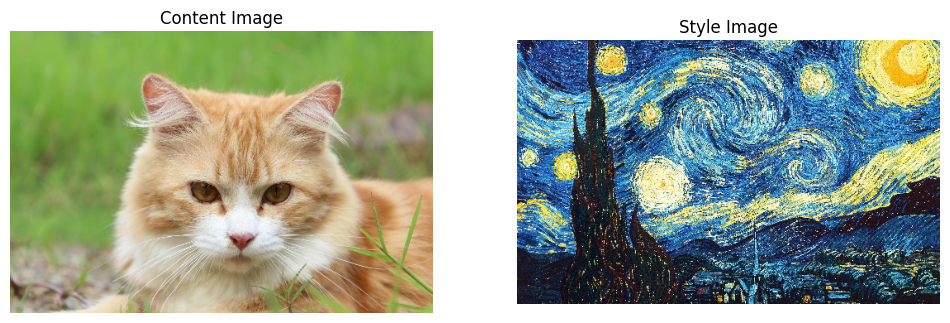

In [ ]:
def tensor_to_image(tensor):
    tensor = tensor*255 # FIXME Convert values from [0, 1] to [0, 255]
    tensor = np.array(tensor, dtype=np.uint8)

    if np.ndim(tensor) > 3:
        assert tensor.shape[0] == 1
        tensor = tensor[0]

    return PIL.Image.fromarray(tensor)

# Visualize input
def load_img(path_to_img):
    path_to_img = str(path_to_img)

    max_dim = 512
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = tf.reduce_max(shape)
    scale = max_dim / long_dim
    new_shape = tf.cast(shape * scale, tf.int32)

    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :]
    return img

# Function to display image
def display_img(image, title=None):
    if len(image.shape) > 3:
        image = tf.squeeze(image, axis=0)
    
    plt.imshow(image)
    plt.axis("off")
    if title:
        plt.title(title)

# Test images
content_image_path = Path("content/content_demo_img.jpeg")
style_image_path = Path("style/style_demo_img.jpeg")

content_image = load_img(content_image_path)
style_image = load_img(style_image_path)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
display_img(content_image, 'Content Image')

plt.subplot(1, 2, 2)
display_img(style_image, 'Style Image')

plt.show()

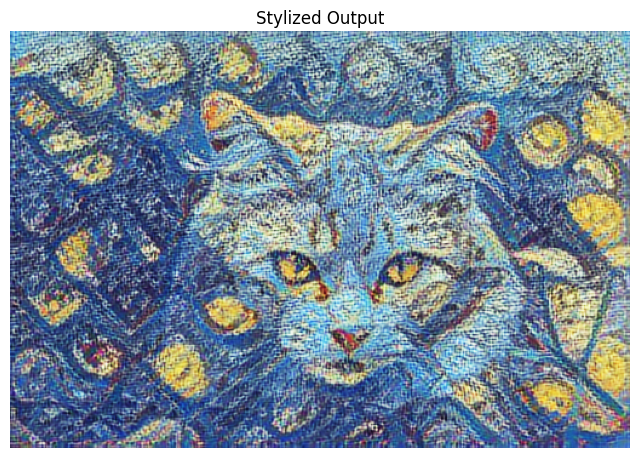

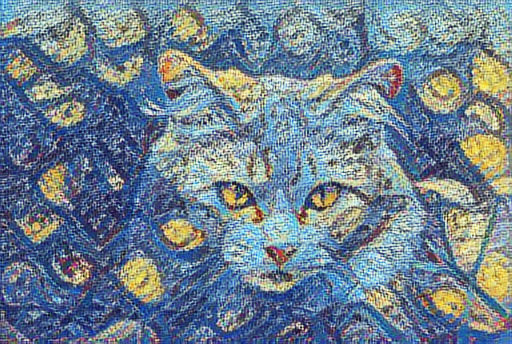

In [11]:
#import tensorflow_hub as hub
hub_model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')
stylized_image = hub_model(tf.constant(content_image), tf.constant(style_image))[0]

plt.figure(figsize=(8, 8))
display_img(stylized_image, "Stylized Output")
plt.show()

result_image = tensor_to_image(stylized_image)
result_image

In [12]:
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

output_path = results_dir / "stylized_output.png"
result_image.save(output_path)

print(f"Saved stylized image to: {output_path}")

Saved stylized image to: results/stylized_output.png


In [13]:
# Notes section for now
# to do:
# - train image content recognition, or find model
# - train image style recognition, or find model
# - get them to extract features / properly identify content

# LATER
# - 